# Visualisasi Data dan Hasil untuk Penelitian Fertilitas Telur Bebek

Notebook ini disusun untuk membantu penyajian visual pada penelitian dan artikel ilmiah.
Fokus utamanya adalah:

1. merangkum distribusi dataset,
2. menampilkan contoh citra candling,
3. membandingkan performa model utama dan baseline,
4. menampilkan confusion matrix model AWC,
5. merangkum seleksi fitur, dan
6. memvisualisasikan hasil uji statistik.

Seluruh figur akan otomatis disimpan ke folder `results/paper_visualizations/` agar mudah dipakai ulang pada naskah, slide, atau lampiran.


In [2]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")

if Path.cwd().name == "notebooks":
    ROOT = Path.cwd().resolve().parent
else:
    ROOT = Path.cwd().resolve()

EXPORT_DIR = ROOT / "results" / "paper_visualizations"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.family": "DejaVu Serif",
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
    }
)

MODEL_COLORS = {
    "AWC": "#1f77b4",
    "KMeans": "#ff7f0e",
    "FCM": "#2ca02c",
    "MobileNetV3": "#d62728",
}

LABEL_TEXT = {
    "fertile": "Fertil",
    "infertile": "Infertil",
}


def save_figure(fig, filename: str):
    path = EXPORT_DIR / f"{filename}.png"
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Tersimpan: {path.relative_to(ROOT)}")
    return path


print(f"Project root : {ROOT}")
print(f"Folder ekspor: {EXPORT_DIR}")


Project root : C:\Users\vanguard\OneDrive\Documents\duck_egg_fertility_detection
Folder ekspor: C:\Users\vanguard\OneDrive\Documents\duck_egg_fertility_detection\results\paper_visualizations


## 1. Memuat sumber data

Bagian ini mengambil data dari hasil eksperimen yang sudah tersedia pada repositori:

- distribusi dataset dari folder `data/train`, `data/val`, dan `data/test`,
- metrik model dari `results/evaluation/full_vascular_glcm_mobilenet/`,
- prediksi sampel dari `results/evaluation/full_evaluation_predictions.csv`,
- metadata fitur dari `data/features/feature_metadata.json`, dan
- hasil evaluasi AWC dari `results/awc_evaluation/metrics.json`.


In [3]:
comparison = pd.read_csv(
    ROOT / "results" / "evaluation" / "full_vascular_glcm_mobilenet" / "comparison_table.csv"
)
predictions = pd.read_csv(ROOT / "results" / "evaluation" / "full_evaluation_predictions.csv")

with open(
    ROOT / "results" / "evaluation" / "full_vascular_glcm_mobilenet" / "full_evaluation_20260427_004032.json",
    "r",
    encoding="utf-8",
) as f:
    full_evaluation = json.load(f)

with open(ROOT / "results" / "awc_evaluation" / "metrics.json", "r", encoding="utf-8") as f:
    awc_metrics = json.load(f)

with open(ROOT / "data" / "features" / "feature_metadata.json", "r", encoding="utf-8") as f:
    feature_metadata = json.load(f)

split_records = []
for split in ["train", "val", "test"]:
    for label in ["fertile", "infertile"]:
        count = len(list((ROOT / "data" / split / label).glob("*.jpg")))
        split_records.append(
            {
                "split": split.capitalize(),
                "kelas": LABEL_TEXT[label],
                "jumlah": count,
            }
        )

dataset_summary = pd.DataFrame(split_records)
dataset_pivot = dataset_summary.pivot(index="split", columns="kelas", values="jumlah").fillna(0).astype(int)
dataset_pivot["Total"] = dataset_pivot.sum(axis=1)
dataset_pivot.loc["Total"] = dataset_pivot.sum(axis=0)

meta_table = pd.DataFrame(
    [
        ("Tanggal evaluasi", full_evaluation["meta"]["timestamp"]),
        ("Jumlah data uji", full_evaluation["meta"]["n_test"]),
        ("Jumlah fitur awal", full_evaluation["meta"]["n_features"]),
        ("Fitur terpilih AWC", full_evaluation["meta"]["awc_selected_features"]),
        ("Arsitektur CNN baseline", f"MobileNetV3-{full_evaluation['meta']['mobilenet_variant']}"),
        ("Ukuran input CNN", f"{full_evaluation['meta']['mobilenet_image_size']} x {full_evaluation['meta']['mobilenet_image_size']} piksel"),
    ],
    columns=["Parameter", "Nilai"],
)

display(dataset_pivot)
display(meta_table)
display(
    comparison.style.format(
        {
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "specificity": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "brier_score": "{:.4f}",
        }
    )
)


kelas,Fertil,Infertil,Total
split,,,
Test,12,12,24
Train,72,84,156
Val,20,24,44
Total,104,120,224


,Parameter,Nilai
0,Tanggal evaluasi,20260427_004032
1,Jumlah data uji,24
2,Jumlah fitur awal,73
3,Fitur terpilih AWC,20
4,Arsitektur CNN baseline,MobileNetV3-small
5,Ukuran input CNN,224 x 224 piksel


,model,accuracy,precision,recall,specificity,f1,roc_auc,brier_score
0,AWC,0.9167,0.8571,1.0000,0.8333,0.9231,0.9514,0.1038
1,KMeans,0.7917,0.8182,0.7500,0.8333,0.7826,0.9167,0.1786
2,FCM,0.8333,0.8333,0.8333,0.8333,0.8333,0.8750,0.1409
3,MobileNetV3,0.5000,0.5000,1.0000,0.0000,0.6667,0.5000,0.2510


## 2. Contoh citra dataset

Figur berikut berguna sebagai ilustrasi visual pada bagian deskripsi dataset. Anda bisa mengganti jumlah sampel, split, atau urutannya sesuai kebutuhan naskah.


Tersimpan: results\paper_visualizations\fig_01_contoh_citra_dataset.png


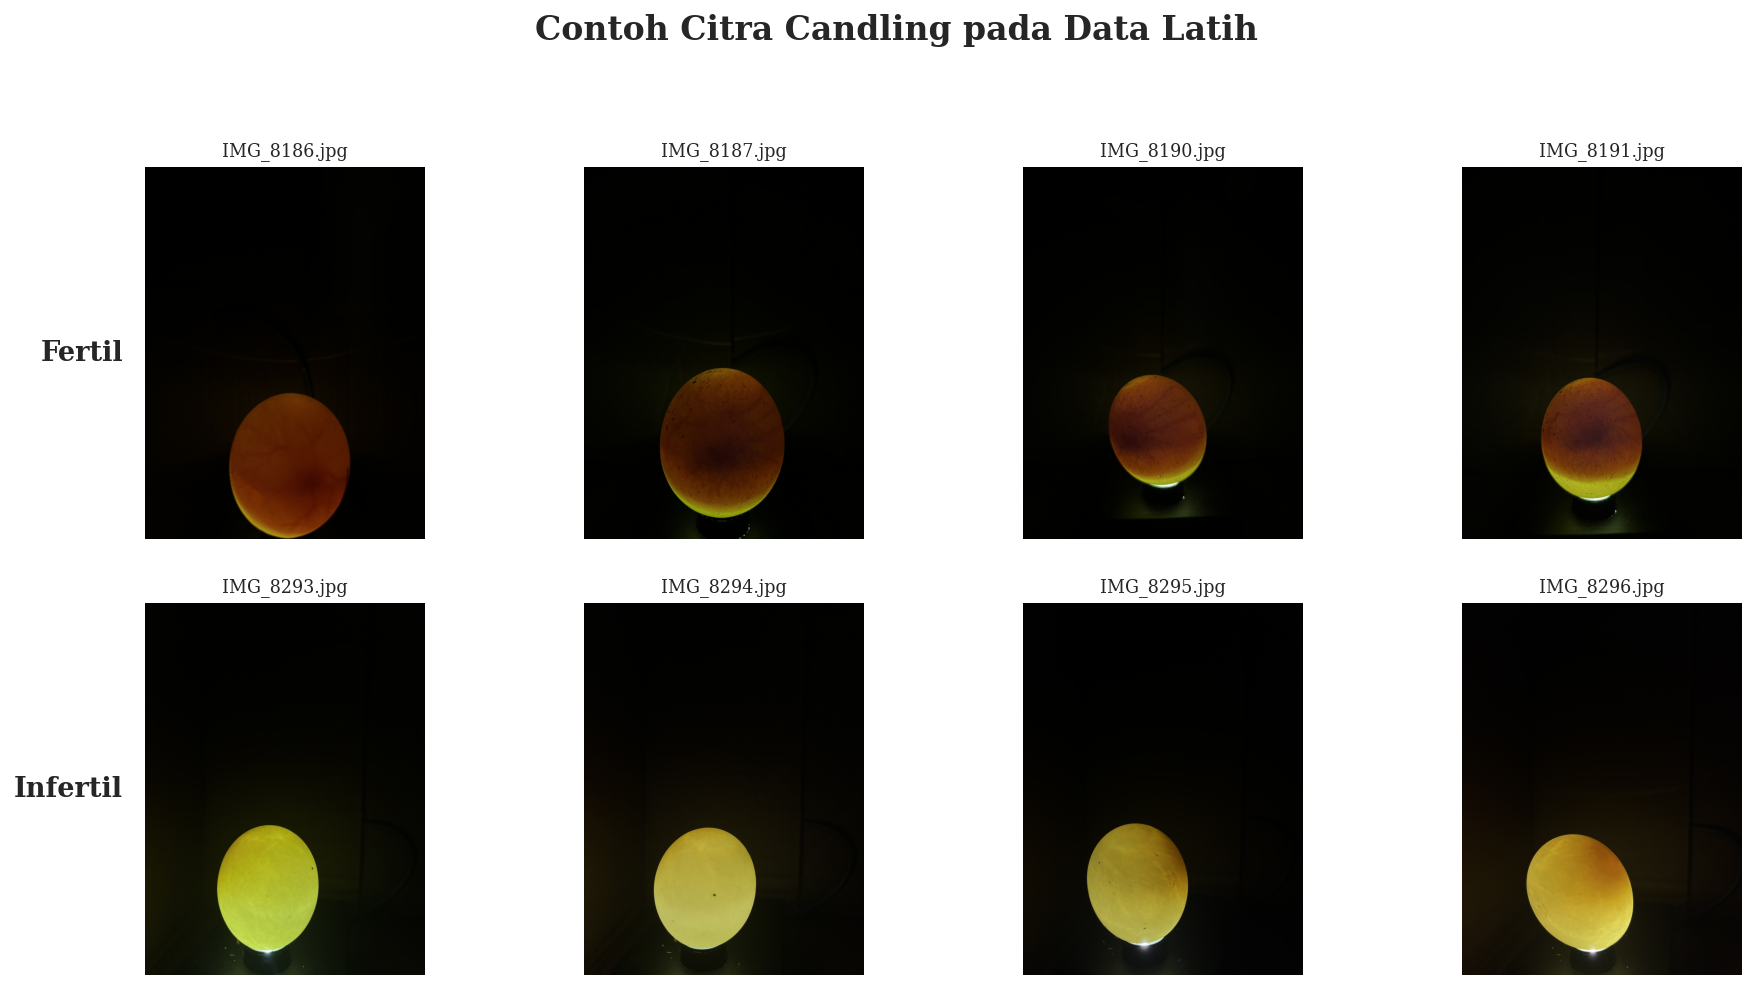

In [4]:
def pick_sample_images(split: str, label: str, n: int = 4):
    return sorted((ROOT / "data" / split / label).glob("*.jpg"))[:n]


sample_paths = {
    "Fertil": pick_sample_images("train", "fertile", n=4),
    "Infertil": pick_sample_images("train", "infertile", n=4),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row_idx, (class_name, paths) in enumerate(sample_paths.items()):
    for col_idx, ax in enumerate(axes[row_idx]):
        if col_idx < len(paths):
            image = Image.open(paths[col_idx]).convert("RGB")
            ax.imshow(image)
            ax.set_title(paths[col_idx].name, fontsize=9)
        ax.axis("off")
    axes[row_idx, 0].text(
        -0.08,
        0.5,
        class_name,
        transform=axes[row_idx, 0].transAxes,
        fontsize=14,
        fontweight="bold",
        va="center",
        ha="right",
    )

fig.suptitle("Contoh Citra Candling pada Data Latih", y=1.02, fontsize=17, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig_01_contoh_citra_dataset")
plt.show()


## 3. Distribusi dataset

Plot ini cocok untuk bagian metodologi atau deskripsi dataset karena memperlihatkan keseimbangan kelas dan pembagian data train-validation-test.


Tersimpan: results\paper_visualizations\fig_02_distribusi_dataset.png


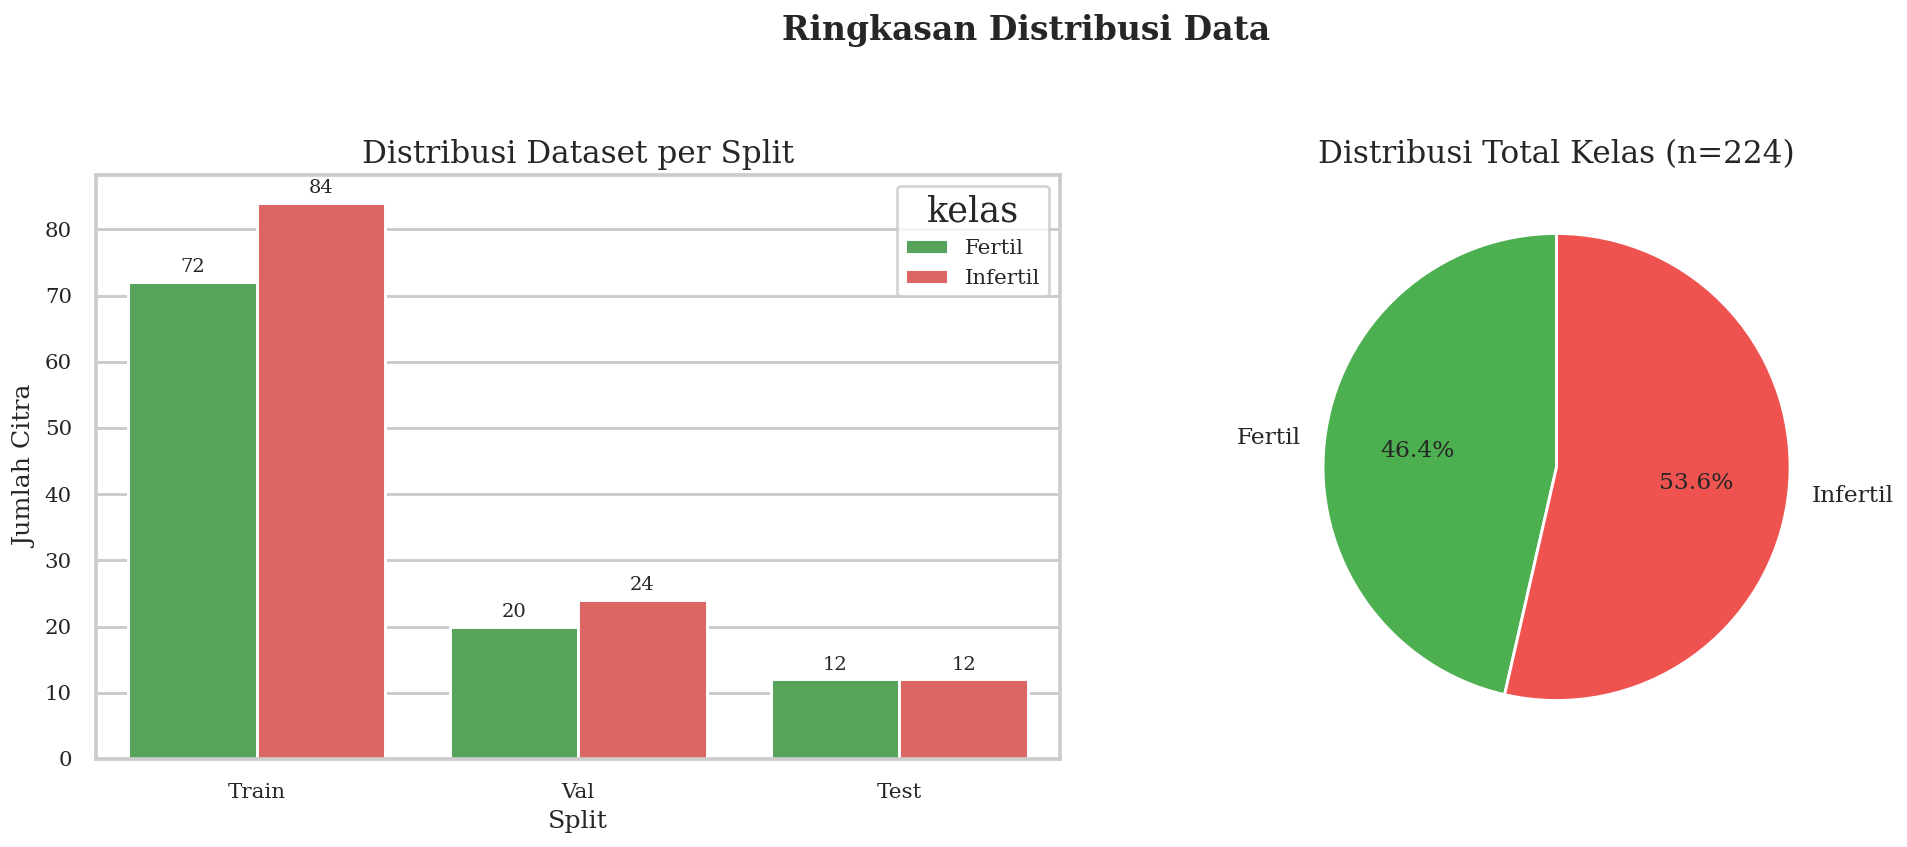

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

order_split = ["Train", "Val", "Test"]
order_class = ["Fertil", "Infertil"]
plot_df = dataset_summary.copy()
plot_df["split"] = pd.Categorical(plot_df["split"], categories=order_split, ordered=True)
plot_df["kelas"] = pd.Categorical(plot_df["kelas"], categories=order_class, ordered=True)
plot_df = plot_df.sort_values(["split", "kelas"])

sns.barplot(
    data=plot_df,
    x="split",
    y="jumlah",
    hue="kelas",
    palette=["#4caf50", "#ef5350"],
    ax=axes[0],
)
axes[0].set_title("Distribusi Dataset per Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Jumlah Citra")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", padding=3, fontsize=10)

total_per_class = (
    dataset_summary.groupby("kelas", as_index=False)["jumlah"].sum().sort_values("kelas")
)
axes[1].pie(
    total_per_class["jumlah"],
    labels=total_per_class["kelas"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4caf50", "#ef5350"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 12},
)
axes[1].set_title(f"Distribusi Total Kelas (n={int(total_per_class['jumlah'].sum())})")

fig.suptitle("Ringkasan Distribusi Data", y=1.02, fontsize=17, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig_02_distribusi_dataset")
plt.show()


## 4. Perbandingan performa model

Visualisasi ini menyoroti posisi model AWC terhadap baseline `KMeans`, `FCM`, dan `MobileNetV3`.
Nilai yang digunakan berasal dari hasil evaluasi pada folder `results/evaluation/full_vascular_glcm_mobilenet/`.


Tersimpan: results\paper_visualizations\fig_03_perbandingan_model.png


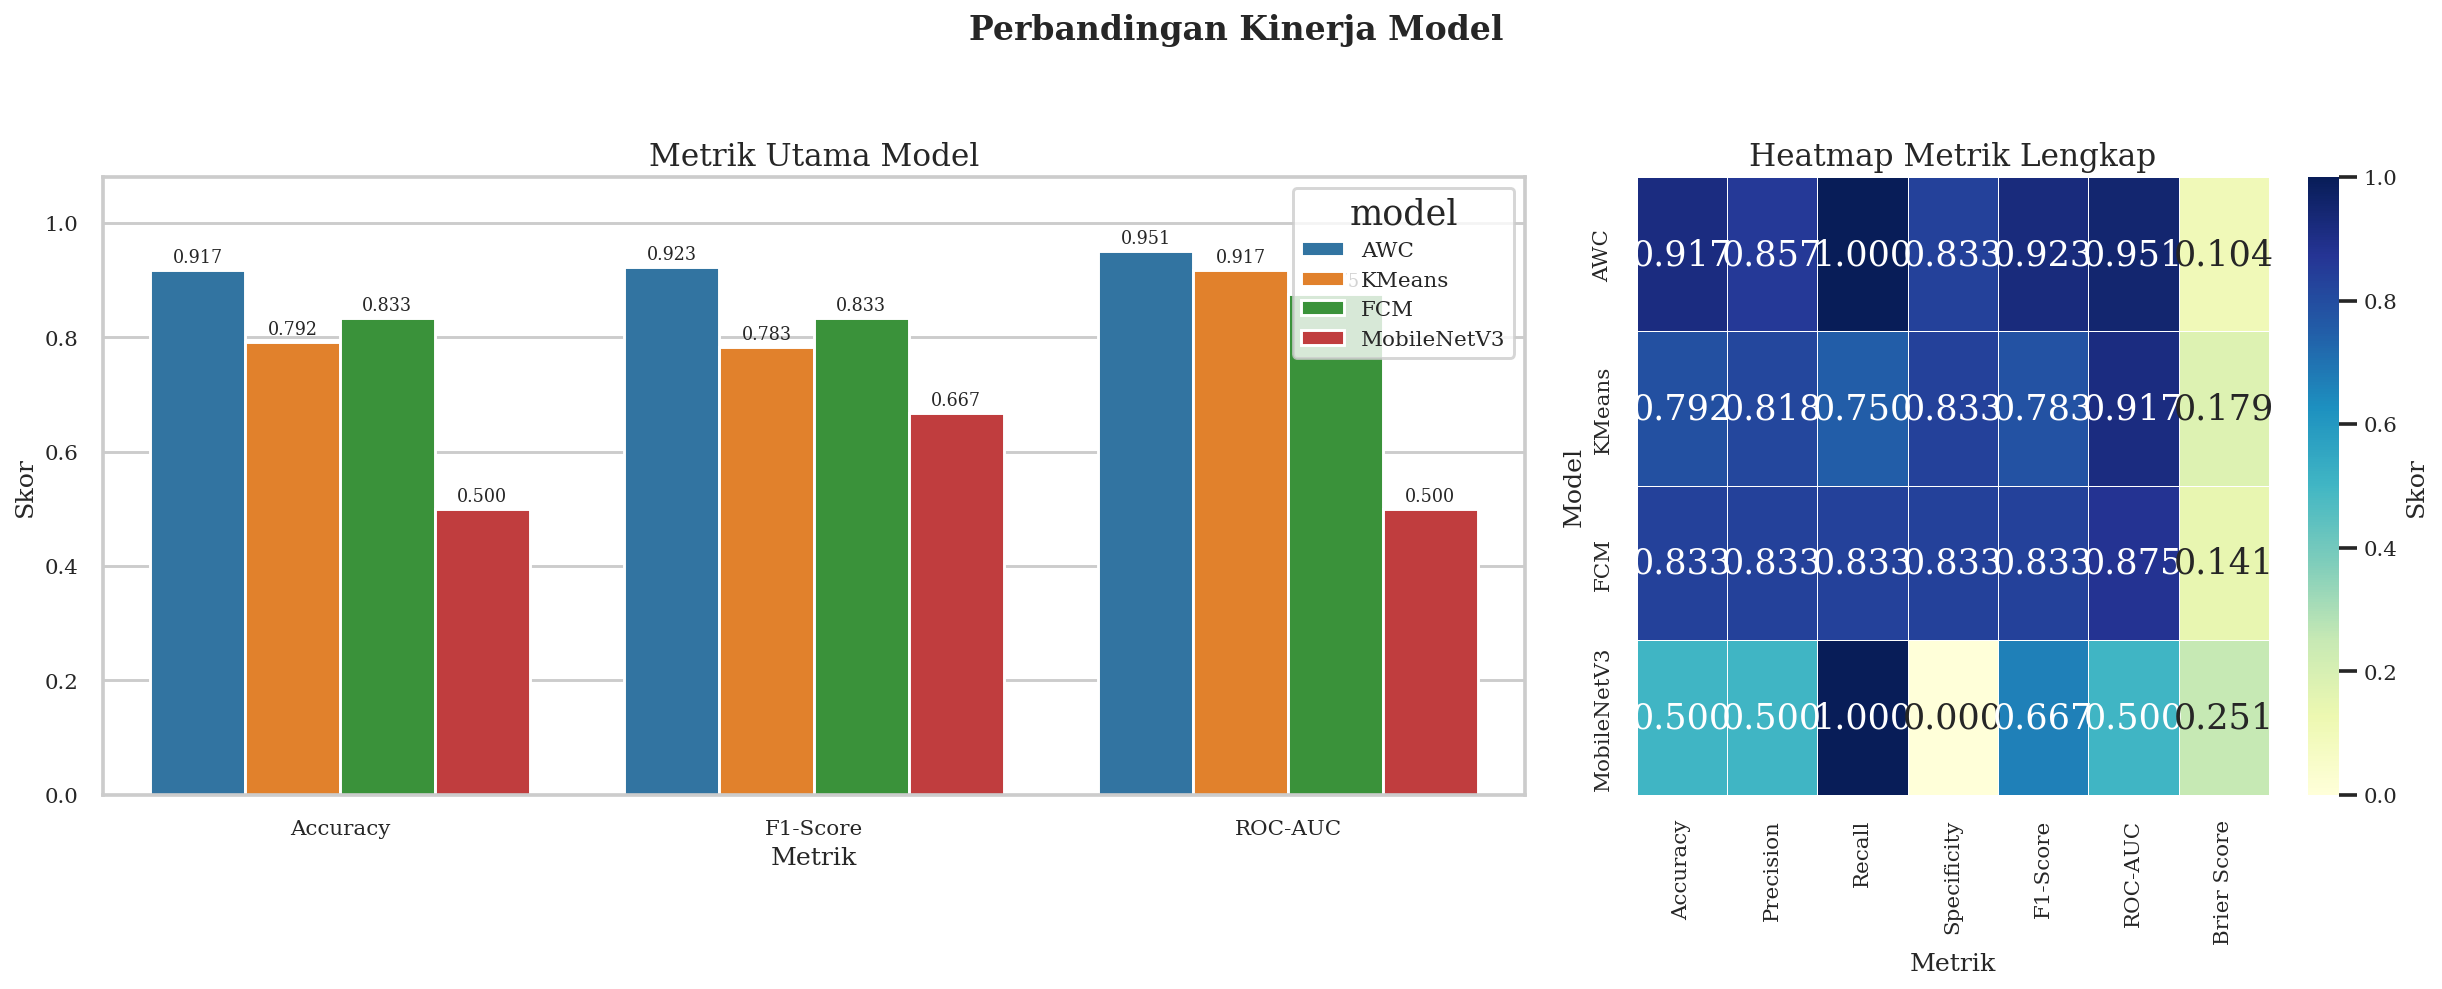

In [6]:
metric_columns = ["accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "brier_score"]
metric_labels = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "specificity": "Specificity",
    "f1": "F1-Score",
    "roc_auc": "ROC-AUC",
    "brier_score": "Brier Score",
}

long_metrics = comparison.melt(
    id_vars="model",
    value_vars=metric_columns,
    var_name="metric",
    value_name="value",
)
long_metrics["metric_label"] = long_metrics["metric"].map(metric_labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [1.8, 1]})

metric_for_bar = long_metrics[long_metrics["metric"].isin(["accuracy", "f1", "roc_auc"])]
sns.barplot(
    data=metric_for_bar,
    x="metric_label",
    y="value",
    hue="model",
    palette=MODEL_COLORS,
    ax=axes[0],
)
axes[0].set_title("Metrik Utama Model")
axes[0].set_xlabel("Metrik")
axes[0].set_ylabel("Skor")
axes[0].set_ylim(0, 1.08)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=2, fontsize=9)

heatmap_data = comparison.set_index("model")[metric_columns].rename(columns=metric_labels)
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Skor"},
    ax=axes[1],
)
axes[1].set_title("Heatmap Metrik Lengkap")
axes[1].set_xlabel("Metrik")
axes[1].set_ylabel("Model")

fig.suptitle("Perbandingan Kinerja Model", y=1.02, fontsize=17, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig_03_perbandingan_model")
plt.show()


## 5. Confusion matrix model terbaik

AWC merupakan model terbaik pada eksperimen utama. Berikut confusion matrix pada data uji (`n = 24`) serta tabel sampel yang salah klasifikasi.


Tersimpan: results\paper_visualizations\fig_04_confusion_matrix_awc.png


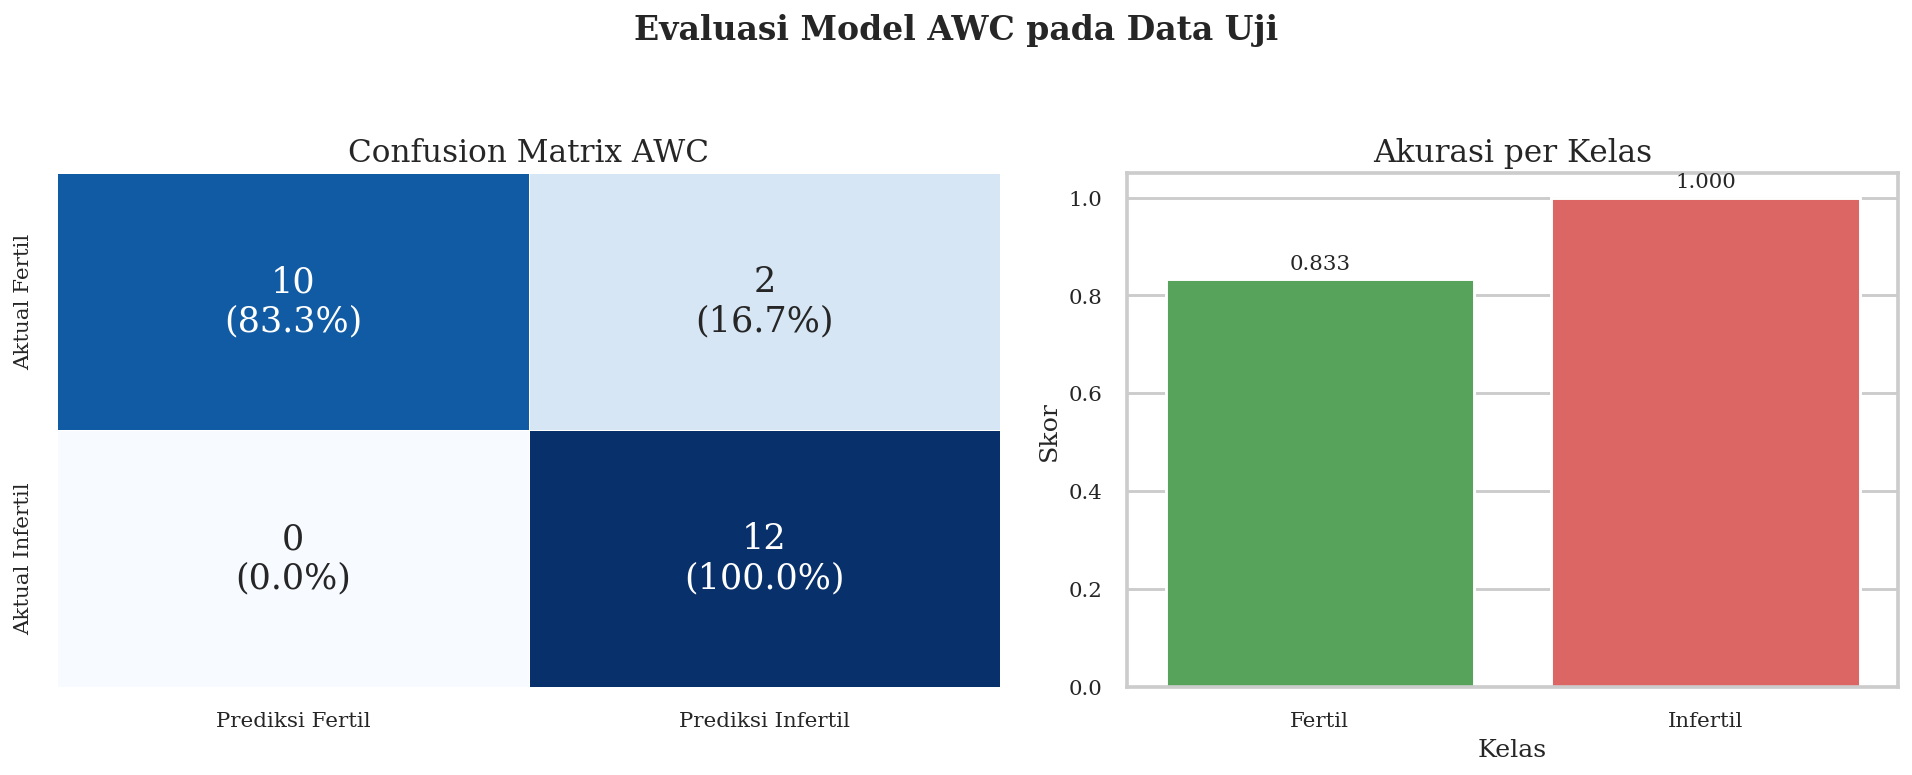

,Nama file,Label aktual,Prediksi AWC
20,IMG_8384.jpg,Infertil,Fertil
22,IMG_8420.jpg,Infertil,Fertil


In [7]:
awc_result = full_evaluation["results"]["AWC"]
y_true = awc_result["y_true"]
y_pred = awc_result["y_pred"]
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.1, 0.9]})

cm_percent = cm / cm.sum(axis=1, keepdims=True)
annot = np.array(
    [[f"{cm[i, j]}\n({cm_percent[i, j]:.1%})" for j in range(cm.shape[1])] for i in range(cm.shape[0])]
)
sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    cbar=False,
    xticklabels=["Prediksi Fertil", "Prediksi Infertil"],
    yticklabels=["Aktual Fertil", "Aktual Infertil"],
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix AWC")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

per_class = pd.DataFrame(
    {
        "kelas": ["Fertil", "Infertil"],
        "akurasi_per_kelas": [
            cm[0, 0] / cm[0].sum(),
            cm[1, 1] / cm[1].sum(),
        ],
    }
)
sns.barplot(
    data=per_class,
    x="kelas",
    y="akurasi_per_kelas",
    palette=["#4caf50", "#ef5350"],
    ax=axes[1],
)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Akurasi per Kelas")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Skor")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", padding=3, fontsize=11)

fig.suptitle("Evaluasi Model AWC pada Data Uji", y=1.02, fontsize=17, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig_04_confusion_matrix_awc")
plt.show()

awc_test_errors = predictions.loc[
    (predictions["split"] == "test") & (predictions["true_label"] != predictions["AWC"]),
    ["image", "true_label", "AWC"],
].copy()
awc_test_errors["true_label"] = awc_test_errors["true_label"].map(LABEL_TEXT)
awc_test_errors["AWC"] = awc_test_errors["AWC"].map(LABEL_TEXT)
awc_test_errors = awc_test_errors.rename(
    columns={"image": "Nama file", "true_label": "Label aktual", "AWC": "Prediksi AWC"}
)
display(awc_test_errors)


## 6. Seleksi fitur oleh AWC

Visualisasi berikut berguna untuk menjelaskan fitur mana yang paling banyak dipertahankan oleh AWC dan bagaimana distribusinya di setiap kelompok fitur.


Tersimpan: results\paper_visualizations\fig_05_seleksi_fitur_awc.png


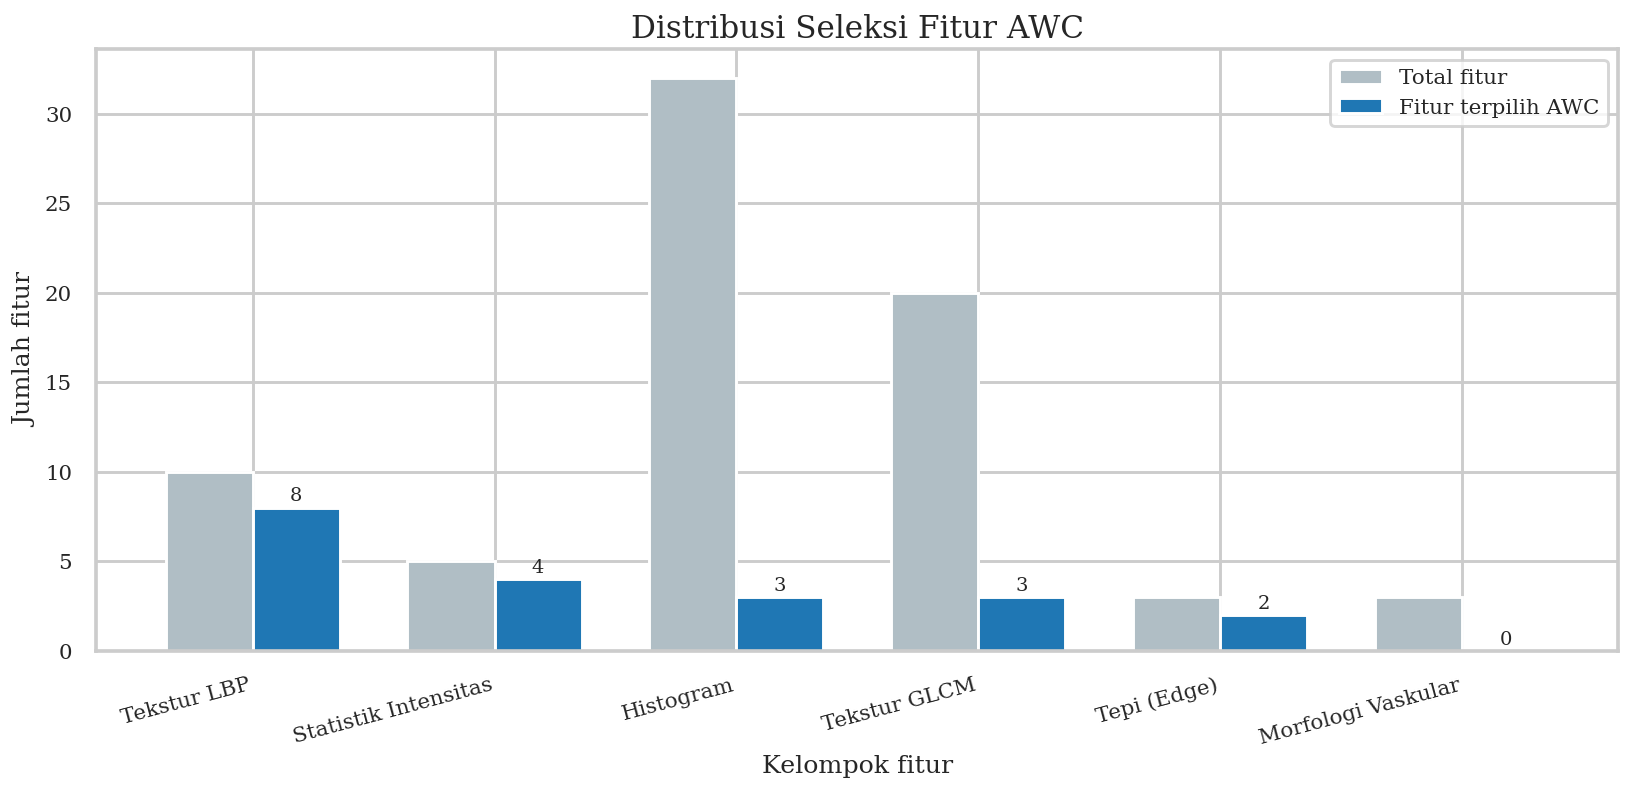

,indeks_fitur,nama_fitur
0,0,mean
1,1,std
2,2,min
3,4,median
4,6,hist_1
5,18,hist_13
6,19,hist_14
7,37,lbp_0
8,38,lbp_1
9,39,lbp_2


In [8]:
selected_indices = set(awc_metrics["selected_feature_indices"])
group_map = feature_metadata["group_map"]
feature_names = feature_metadata["feature_names"]

feature_group_rows = []
for group_name, indices in group_map.items():
    feature_group_rows.append(
        {
            "kelompok_fitur": group_name,
            "total_fitur": len(indices),
            "fitur_terpilih": sum(1 for idx in indices if idx in selected_indices),
        }
    )

feature_group_df = pd.DataFrame(feature_group_rows).sort_values("fitur_terpilih", ascending=False)
selected_feature_names = pd.DataFrame(
    {
        "indeks_fitur": awc_metrics["selected_feature_indices"],
        "nama_fitur": [feature_names[idx] for idx in awc_metrics["selected_feature_indices"]],
    }
)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(feature_group_df))
width = 0.36

ax.bar(
    x - width / 2,
    feature_group_df["total_fitur"],
    width=width,
    label="Total fitur",
    color="#b0bec5",
)
ax.bar(
    x + width / 2,
    feature_group_df["fitur_terpilih"],
    width=width,
    label="Fitur terpilih AWC",
    color="#1f77b4",
)

ax.set_xticks(x)
ax.set_xticklabels(feature_group_df["kelompok_fitur"], rotation=15, ha="right")
ax.set_ylabel("Jumlah fitur")
ax.set_xlabel("Kelompok fitur")
ax.set_title("Distribusi Seleksi Fitur AWC")
ax.legend()

for xpos, value in zip(x + width / 2, feature_group_df["fitur_terpilih"]):
    ax.text(xpos, value + 0.15, str(int(value)), ha="center", va="bottom", fontsize=10)

fig.tight_layout()
save_figure(fig, "fig_05_seleksi_fitur_awc")
plt.show()

display(selected_feature_names)


## 7. Uji statistik antar model

Plot ini memudahkan penulisan bagian analisis statistik. Notebook menggunakan hasil Wilcoxon dari evaluasi utama dan langsung menandai pasangan yang signifikan pada `alpha = 0.05`.


Tersimpan: results\paper_visualizations\fig_06_uji_wilcoxon.png


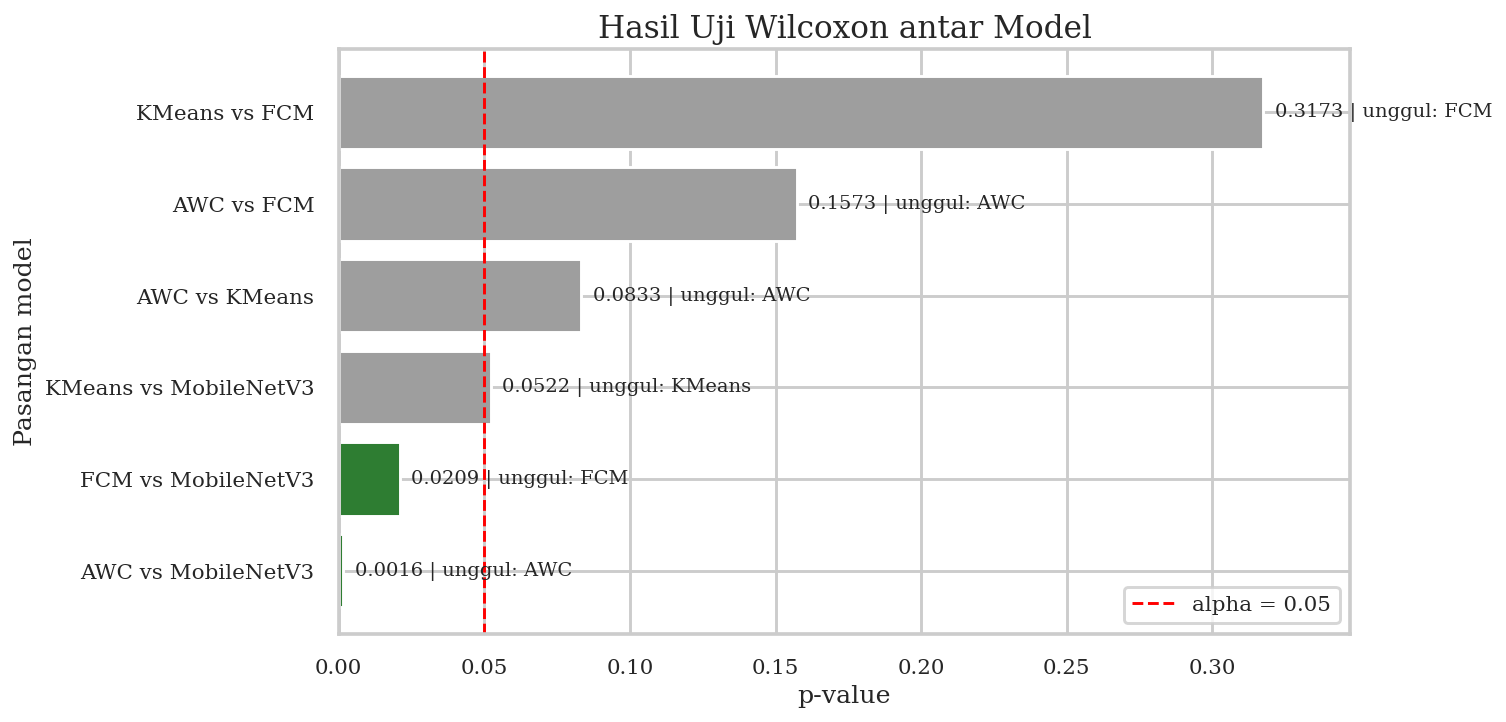

,pasangan_model,p_value,signifikan,model_lebih_baik,catatan
2,AWC vs MobileNetV3,0.001565,True,AWC,p=0.0016 (significant at alpha=0.05)
5,FCM vs MobileNetV3,0.020921,True,FCM,p=0.0209 (significant at alpha=0.05)
4,KMeans vs MobileNetV3,0.052204,False,KMeans,p=0.0522 (not significant at alpha=0.05)
0,AWC vs KMeans,0.083265,False,AWC,p=0.0833 (not significant at alpha=0.05)
1,AWC vs FCM,0.157299,False,AWC,p=0.1573 (not significant at alpha=0.05)
3,KMeans vs FCM,0.317311,False,FCM,p=0.3173 (not significant at alpha=0.05)


In [9]:
wilcoxon_rows = []
for pair_name, result in full_evaluation["wilcoxon"].items():
    wilcoxon_rows.append(
        {
            "pasangan_model": pair_name.replace("_vs_", " vs "),
            "p_value": result["p_value"],
            "signifikan": result["significant"],
            "model_lebih_baik": result["better_model"],
            "catatan": result["note"].replace("α", "alpha"),
        }
    )

wilcoxon_df = pd.DataFrame(wilcoxon_rows).sort_values("p_value", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ["#2e7d32" if flag else "#9e9e9e" for flag in wilcoxon_df["signifikan"]]
bars = ax.barh(wilcoxon_df["pasangan_model"], wilcoxon_df["p_value"], color=colors)
ax.axvline(0.05, color="red", linestyle="--", linewidth=1.5, label="alpha = 0.05")
ax.set_xlabel("p-value")
ax.set_ylabel("Pasangan model")
ax.set_title("Hasil Uji Wilcoxon antar Model")
ax.legend()

for bar, (_, row) in zip(bars, wilcoxon_df.iterrows()):
    ax.text(
        row["p_value"] + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{row['p_value']:.4f} | unggul: {row['model_lebih_baik']}",
        va="center",
        fontsize=10,
    )

ax.set_xlim(0, max(0.08, wilcoxon_df["p_value"].max() + 0.03))
fig.tight_layout()
save_figure(fig, "fig_06_uji_wilcoxon")
plt.show()

display(wilcoxon_df)


## 8. Ringkasan file figur

Bagian ini menampilkan seluruh figur yang sudah diekspor. Jika Anda ingin mengubah gaya, resolusi, atau nama file, cukup edit sel terkait lalu jalankan ulang notebook.


In [10]:
exported_files = sorted(EXPORT_DIR.glob("*.png"))
exported_table = pd.DataFrame(
    {
        "nama_file": [path.name for path in exported_files],
        "lokasi": [str(path.relative_to(ROOT)) for path in exported_files],
    }
)
display(exported_table)


,nama_file,lokasi
0,fig_01_contoh_citra_dataset.png,results\paper_visualizations\fig_01_contoh_cit...
1,fig_02_distribusi_dataset.png,results\paper_visualizations\fig_02_distribusi...
2,fig_03_perbandingan_model.png,results\paper_visualizations\fig_03_perbanding...
3,fig_04_confusion_matrix_awc.png,results\paper_visualizations\fig_04_confusion_...
4,fig_05_seleksi_fitur_awc.png,results\paper_visualizations\fig_05_seleksi_fi...
5,fig_06_uji_wilcoxon.png,results\paper_visualizations\fig_06_uji_wilcox...
